In [29]:
from autoencoder import autoencoder, build_autoencoder
import cProfile as profile
import pstats

### Configuration

In [30]:
#'NIST/PIEdataRaw1'
"""
'dataset'                : "NIST/PIEdataRaw1",
        'path_save'              : 'Autoencoder Log/',
        'input_dimension'        : 800
"""
#8192 NIST
#496 oxford
#800 NIST (short)
#['GELU', 'Softplus', 'GELU']
config = {
'files' : {
        'dataset'                : "NIST 1 (short)",
        'path_save'              : 'Autoencoder Log/',
        'input_dimension'        : 800
        },
'sweep' : {
        'sweep_name'             : None,
        'activation_possibilty'  : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                        'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                        'Mish', 'Softplus', 'Softsign', 'Tanh'],
        'layer_possibility'      : {'number' : [4],
                                    'size'   : [5,50,75,100],
                                   },
        'search_type'            : 'random_search',
        'search_param'           : ['activation_possibilty','layer_possibility']
        },
'run' : {
        'activation_list'        : ['Sigmoid', 'Sigmoid', 'Sigmoid'],
        'layer_list'             : [400, 100, 2, 100, 400],
        'layer_number'           : 4
        },
'network' : {
        'output_dimension'       : 2,
        'skip_elements'          : 2,
        'layer_type'             : 'Linear',
        'layer_conv'             : True
        },
'train' : {
        'train_size'             : 0.8,
        'batch_number'           : 1,
        'k-fold'                 : 2, 
        'optimizer'              : 'adam',
        'criterion'              : 'MSELoss',
        'epochs'                 : 10,
        'learning_rate'          : 5e-7,
        }
}

experiment = autoencoder()
model = build_autoencoder

### Run

In [31]:
prof = profile.Profile()
prof.enable()
experiment.run(model, config)
prof.disable()

Fold:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
stats = pstats.Stats(prof).strip_dirs().sort_stats("cumtime")
stats.print_stats(10)

         4670873381 function calls (4519719994 primitive calls) in 18789.697 seconds

   Ordered by: cumulative time
   List reduced from 631 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000 18789.697 9394.848 interactiveshell.py:3472(run_code)
        2    0.000    0.000 18789.697 9394.848 {built-in method builtins.exec}
        1    0.397    0.397 18789.697 18789.697 103957926.py:3(<module>)
        1    3.456    3.456 18789.300 18789.300 autoencoder.py:510(run)
       40  217.331    5.433 18206.067  455.152 autoencoder.py:377(train_epoch)
 12288000  149.000    0.000 11140.234    0.001 optimizer.py:265(wrapper)
 12288000   64.290    0.000 10562.277    0.001 optimizer.py:29(_use_grad)
 12288000   54.859    0.000 10454.787    0.001 adam.py:108(step)
 12288000   40.987    0.000 10043.575    0.001 adam.py:231(adam)
 12288000 3201.609    0.000 9894.226    0.001 adam.py:300(_single_tensor_adam)




### Sweep

In [ ]:
#experiment.sweep("sweep1", 2, model, config)

### Load

Activation list :  ['GELU', 'Softplus', 'GELU']
Layer list :  [400, 100, 2, 100, 400]


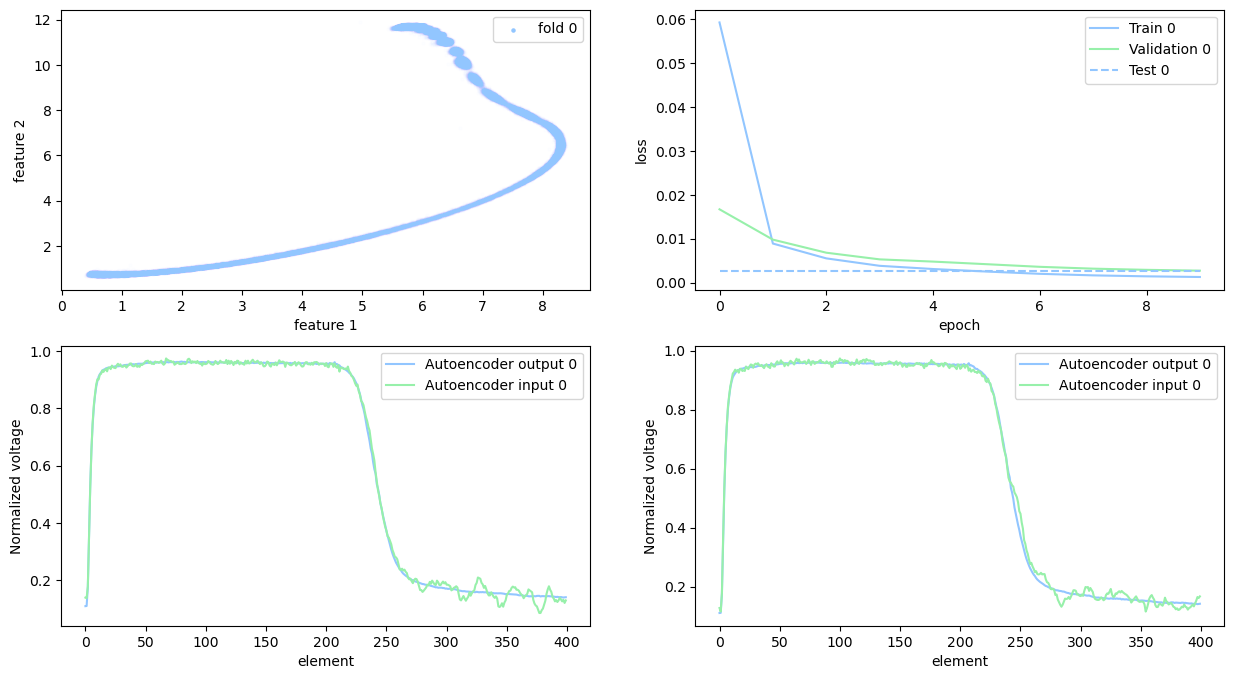

In [ ]:
experiment.load_results("run-2023-06-29-06-55")